## 1) Carregamento dos Dados

Nesta etapa, carregamos os dados da ação da Uber a partir de um arquivo CSV. Verificamos as primeiras linhas da base para entender sua estrutura.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import kpss

# Carregar dados
file_path = "../../database/uber_stock_data.csv"
df = pd.read_csv(file_path)

print("Dados iniciais:")
print(df.head())

Dados iniciais:
         Date  Adj Close      Close       High        Low       Open  \
0  2019-05-10  41.570000  41.570000  45.000000  41.060001  42.000000   
1  2019-05-13  37.099998  37.099998  39.240002  36.080002  38.790001   
2  2019-05-14  39.959999  39.959999  39.959999  36.849998  38.310001   
3  2019-05-15  41.290001  41.290001  41.880001  38.950001  39.369999   
4  2019-05-16  43.000000  43.000000  44.060001  41.250000  41.480000   

      Volume  
0  186322500  
1   79442400  
2   46661100  
3   36086100  
4   38115500  


## 2) Limpeza e Tratamento Inicial

Nesta etapa são realizados:

- Tratamento de valores ausentes (média para variáveis numéricas).
- Remoção de duplicatas.
- Conversão da coluna 'Date' para o formato datetime.
- Criação das variáveis de data (Ano, Mês, Dia).

In [5]:
# Tratamento de valores ausentes
print("\nValores ausentes antes do tratamento:")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

print("Valores ausentes após tratamento:")
print(df.isnull().sum())

# Remover duplicatas
print(f"\nLinhas antes da remoção de duplicatas: {df.shape[0]}")
df = df.drop_duplicates()
print(f"Linhas após remoção de duplicatas: {df.shape[0]}")

# Conversão de data
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Definir índice
df.set_index('Date', inplace=True)



Valores ausentes antes do tratamento:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Valores ausentes após tratamento:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Linhas antes da remoção de duplicatas: 1444
Linhas após remoção de duplicatas: 1444


## 3) Remoção de Outliers (Z-Score)

Remoção de outliers com base no Z-Score. Valores que estão a mais de 3 desvios padrão da média são removidos.

In [6]:
def remove_outliers_zscore(data, cols, threshold=3):
    df_filtered = data.copy()
    for col in cols:
        if df_filtered[col].dtype in [np.float64, np.int64]:
            mean = df_filtered[col].mean()
            std = df_filtered[col].std()
            df_filtered = df_filtered[np.abs(df_filtered[col] - mean) <= threshold * std]
    return df_filtered

numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(['Year','Month','Day'])
df = remove_outliers_zscore(df, numeric_cols)
print(f"\nDimensão após remoção de outliers: {df.shape}")



Dimensão após remoção de outliers: (1421, 9)


## 4) Análise de Correlação

Geramos uma matriz de correlação para entender a relação entre as variáveis. A coluna 'Adj Close' é removida devido à alta correlação com 'Close'.

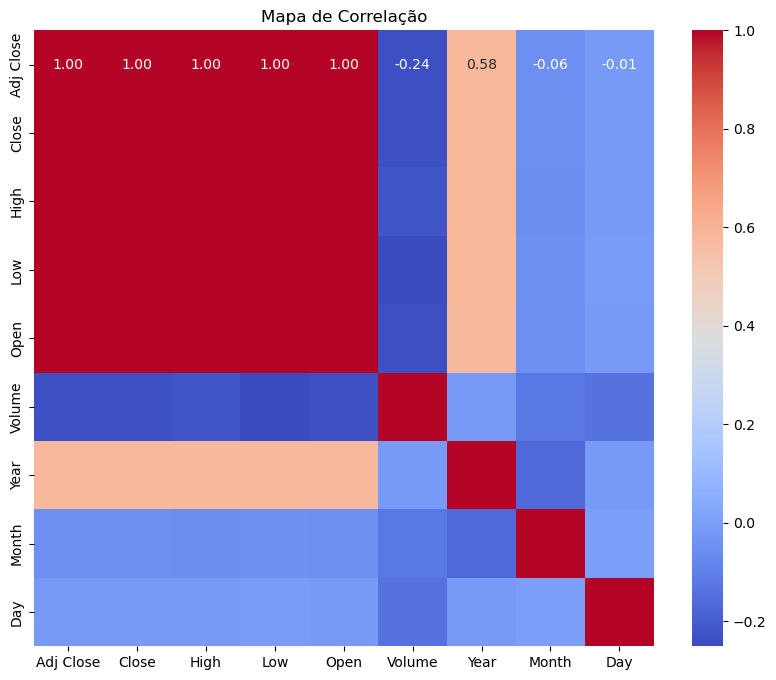

Coluna 'Adj Close' removida devido alta correlação com 'Close'.


In [7]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação')
plt.show()

# Remover coluna altamente correlacionada
if 'Adj Close' in df.columns:
    df = df.drop(columns=['Adj Close'])
    print("Coluna 'Adj Close' removida devido alta correlação com 'Close'.")

## 5) Criação de Variáveis Derivadas

Calculamos duas novas variáveis:

- `Daily_Return`: retorno diário percentual.
- `Price_Change`: diferença entre o preço de fechamento e de abertura.


In [8]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Price_Change'] = df['Close'] - df['Open']

## 6) Normalização dos Dados

Aplicamos a normalização utilizando `StandardScaler` para padronizar os dados.

In [9]:
scaler = StandardScaler()
cols_to_normalize = df.select_dtypes(include=[np.number]).columns.difference(['Year','Month','Day'])
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print("\nDados normalizados - estatísticas:")
print(df.describe())


Dados normalizados - estatísticas:
              Close          High           Low          Open        Volume  \
count  1.421000e+03  1.421000e+03  1.421000e+03  1.421000e+03  1.421000e+03   
mean  -2.800168e-16  2.000120e-17 -4.000241e-16  1.400084e-16 -5.500331e-17   
std    1.000352e+00  1.000352e+00  1.000352e+00  1.000352e+00  1.000352e+00   
min   -1.643076e+00 -1.590039e+00 -1.661889e+00 -1.560716e+00 -1.659338e+00   
25%   -8.059705e-01 -8.047075e-01 -8.104323e-01 -8.079206e-01 -6.729775e-01   
50%   -1.962352e-01 -2.109514e-01 -2.049234e-01 -2.102818e-01 -2.267064e-01   
75%    6.588033e-01  6.631897e-01  6.458873e-01  6.644674e-01  4.422407e-01   
max    2.675669e+00  2.640473e+00  2.609595e+00  2.620841e+00  4.632124e+00   

              Year        Month          Day  Daily_Return  Price_Change  
count  1421.000000  1421.000000  1421.000000  1.420000e+03  1.421000e+03  
mean   2021.712878     6.691766    15.885292 -1.000764e-17 -7.500451e-18  
std       1.680638     3.42

## 7) Visualização dos Dados

Realizamos as seguintes visualizações:

- Distribuição das variáveis normalizadas.
- Média dos preços por ano.

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


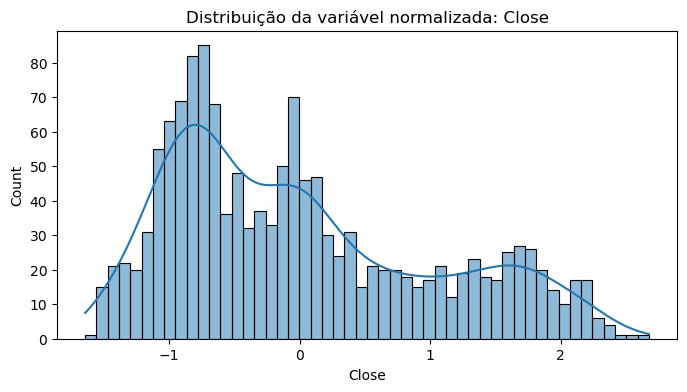

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


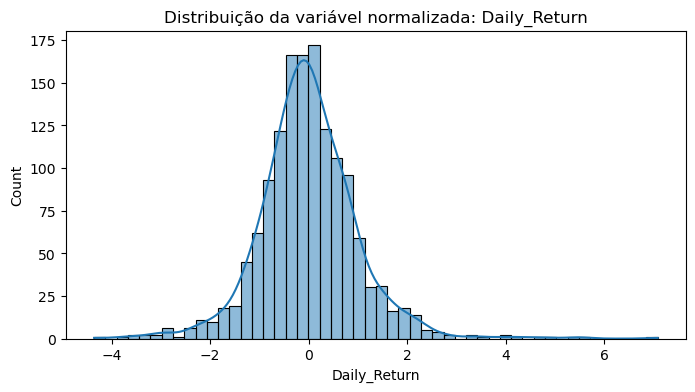

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


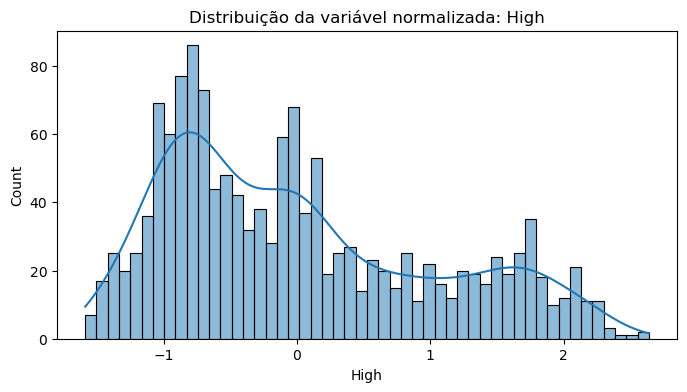

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


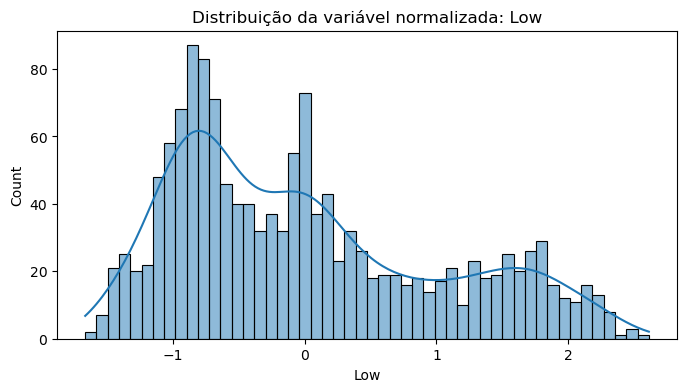

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


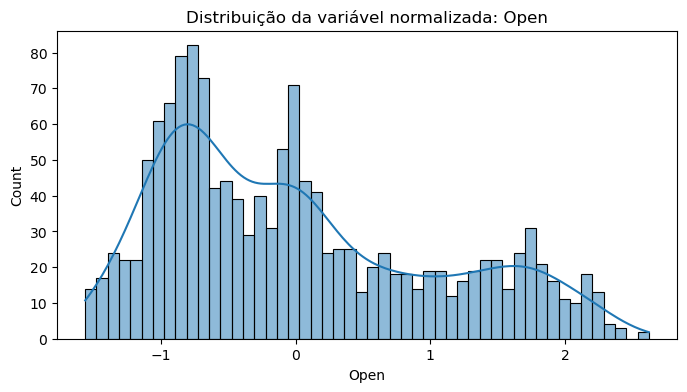

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


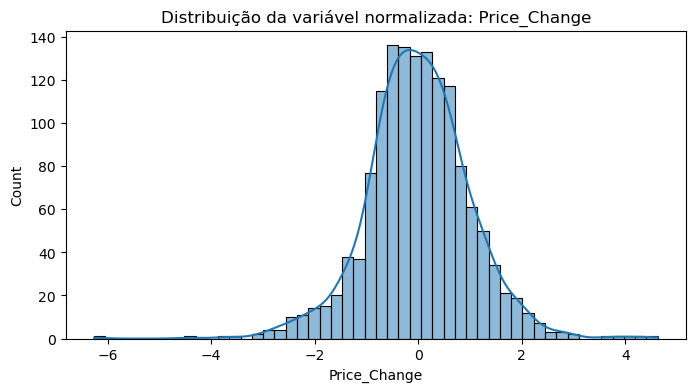

c:\Users\kmhar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


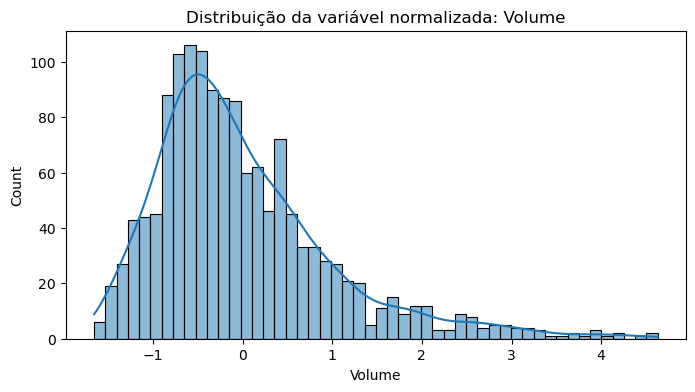

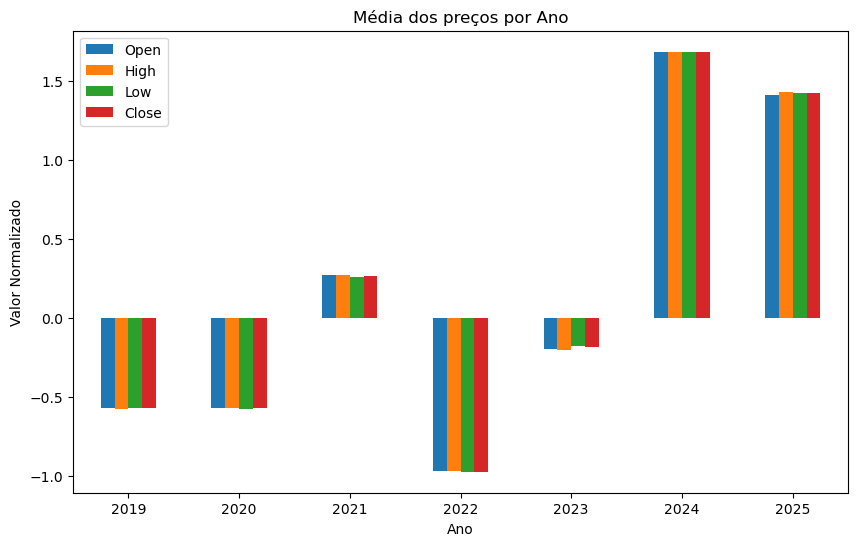

In [10]:
# Distribuição das variáveis
for col in cols_to_normalize:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribuição da variável normalizada: {col}')
    plt.show()

# Média dos preços por ano
mean_prices_by_year = df.groupby('Year')[['Open', 'High', 'Low', 'Close']].mean()
mean_prices_by_year.plot(kind='bar', figsize=(10,6))
plt.title('Média dos preços por Ano')
plt.ylabel('Valor Normalizado')
plt.xlabel('Ano')
plt.xticks(rotation=0)
plt.show()

## 8) Análise de Tendência (Regressão Polinomial e LOESS)

Aplicamos duas técnicas de suavização para identificar tendências nos dados de preços normalizados:

- **Regressão Polinomial (grau 3)**: Captura tendências não lineares.
- **LOESS (Locally Estimated Scatterplot Smoothing)**: Técnica de suavização não paramétrica.

Esses modelos ajudam a visualizar o comportamento do preço ao longo do tempo.


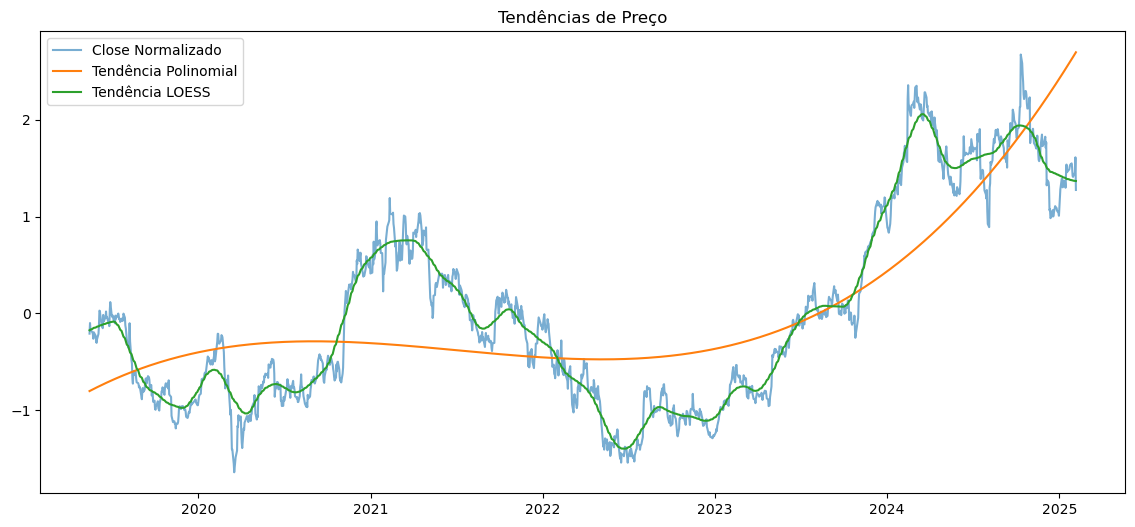

In [11]:
# Remover valores nulos do cálculo anterior
df = df.dropna(subset=['Daily_Return'])

# Criar variável de tempo em dias
df['Days'] = (df.index - df.index.min()).days

# Variáveis para regressão
X = df['Days'].values.reshape(-1,1)
y = df['Close'].values

# Regressão Polinomial (grau 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
df['PolyTrend'] = model.predict(X_poly)

# LOESS
loess_smoothed = lowess(df['Close'], np.arange(len(df)), frac=0.05)
df['LoessTrend'] = np.interp(np.arange(len(df)), np.arange(len(loess_smoothed)), loess_smoothed[:,1])

# Plotar tendências
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Close Normalizado', alpha=0.6)
plt.plot(df.index, df['PolyTrend'], label='Tendência Polinomial')
plt.plot(df.index, df['LoessTrend'], label='Tendência LOESS')
plt.title('Tendências de Preço')
plt.legend()
plt.show()


## 9) Teste de Estacionariedade (KPSS)

O teste de estacionariedade KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é aplicado para verificar se a série temporal dos preços é estacionária.

Interpretando o teste:
- Se o p-valor < 0.05, rejeitamos a hipótese nula e a série **não é estacionária**.
- Se o p-valor ≥ 0.05, a série **é estacionária**.

Aplicamos o teste na série original e também na série diferenciada (primeira diferença).


In [12]:
def kpss_test(series):
    statistic, p_value, _, critical_values = kpss(series.dropna(), regression='c')
    print(f"KPSS Estatística: {statistic:.4f}, p-valor: {p_value:.4f}")
    if p_value < 0.05:
        print("=> Série NÃO é estacionária.")
    else:
        print("=> Série é estacionária.")

# Teste na série original
print("Teste KPSS para série original 'Close':")
kpss_test(df['Close'])

# Teste na série diferenciada
df['Close_Diff'] = df['Close'].diff()
print("\nTeste KPSS para série diferenciada 'Close_Diff':")
kpss_test(df['Close_Diff'])


Teste KPSS para série original 'Close':
KPSS Estatística: 2.1658, p-valor: 0.0100
=> Série NÃO é estacionária.

Teste KPSS para série diferenciada 'Close_Diff':
KPSS Estatística: 0.0951, p-valor: 0.1000
=> Série é estacionária.


C:\Users\kmhar\AppData\Local\Temp\ipykernel_22156\2975421591.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, _, critical_values = kpss(series.dropna(), regression='c')
C:\Users\kmhar\AppData\Local\Temp\ipykernel_22156\2975421591.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, _, critical_values = kpss(series.dropna(), regression='c')


## 10) Resultados Finais e Exportação dos Dados

- Sumário estatístico dos dados finais tratados e normalizados.
- Verificação das dimensões finais da base.
- Salvamento dos dados processados em um arquivo CSV para uso posterior.

In [13]:
print("\nDescrição final da base tratada:")
print(df.describe())

print(f"Dimensão final: {df.shape}")

# Exportar dados tratados
df.reset_index().to_csv("dados_tratados_normalizados.csv", index=False)
print("Dados tratados e normalizados salvos em 'dados_tratados_normalizados.csv'")


Descrição final da base tratada:
             Close         High          Low         Open       Volume  \
count  1420.000000  1420.000000  1420.000000  1420.000000  1420.000000   
mean      0.000208     0.000242     0.000314     0.000283    -0.001425   
std       1.000674     1.000663     1.000634     1.000648     0.999261   
min      -1.643076    -1.590039    -1.661889    -1.560716    -1.659338   
25%      -0.806131    -0.804866    -0.810513    -0.808080    -0.673371   
50%      -0.195915    -0.210000    -0.204278    -0.204535    -0.227030   
75%       0.658803     0.664871     0.647985     0.666064     0.441826   
max       2.675669     2.640473     2.609595     2.620841     4.632124   

              Year        Month          Day  Daily_Return  Price_Change  \
count  1420.000000  1420.000000  1420.000000  1.420000e+03   1420.000000   
mean   2021.714789     6.692958    15.886620 -1.250956e-17     -0.001110   
std       1.679686     3.427301     8.768527  1.000352e+00      0.99982